In [14]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
archivo = "/content/diabetes (1).csv"
completo = pd.read_csv(archivo)

for df in (completo,):
  df.columns = [str(c).strip() for c in df.columns]

columnas_nulas = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']    # Variables donde 0 representa un valor nulo

In [17]:
# 2. Separación en Completo, Depurado y Excluidas
depurado = completo.copy()
filtro_ceros = (depurado[columnas_nulas] == 0).any(axis=1)

excluidas = depurado[filtro_ceros].copy()
depurado = depurado[~filtro_ceros].dropna().copy()
completo = completo.dropna().copy()

print(f"Registros totales: {len(completo):,}")
print(f"Registros depurados: {len(depurado):,}")
print(f"Registros excluidos: {len(excluidas):,}")

display(completo.head(10))

Registros totales: 768
Registros depurados: 768
Registros excluidos: 0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
5,5,116,74.0,27,102.5,25.6,0.201,30,0
6,3,78,50.0,32,88.0,31.0,0.248,26,1
7,10,115,70.0,27,102.5,35.3,0.134,29,0
8,2,197,70.0,45,543.0,30.5,0.158,53,1
9,8,125,96.0,32,169.5,34.3,0.232,54,1


**Medidas de tendencia central**

|Medida | Definicion | Utilidad |
|---|---|---|
|Media| Suma de frecuencias divida entre palabras unicas|Frecuencia promedio, sensible a plabras extremadamente repetidas|
|Mediana| Valor central de las frecuencias ordenadas | Describe mejor una dsitribucion no simetrica|
|Moda| Frecuencia que ocurre en mas palabras|Mostrar muchos palabras que aparecen una vez|
|Cuartiles|Dividen los datos ordenados en 4 partes|Localizar el 25%, 50% y 75% de las frecuencias|
|Varianza| Promedio de desviaciones cuadraticas con respecto a la media| Cualifica la dispercion|
|Desviacion Estandar| raiz de la varianza | Dispersion en las mismas unidades de frecuencia|
|IQR - Rango Intercuartilico| Q3 - Q1 | Mide una dispersion mas robusta del 50% central|
|Asimetria| Mide la falta de simetria| Un valor alto revela una cola de palabras muy frecuentes|
|Gini| Sirve para medir la desigualdad economica o la concentracion de ingresos de una poblacion|Medir que tan aprecida o diferente es la distribucion de los recursos de un grupo de personas|
|Entropia|Medir el grado de desorden, caos o incertidumbre dentro de un sistema|Medir la incertidumbre, el desorden o la perdida de control en cualquier sistema|

In [18]:
# Funciones de gini y entropia
def gini(valores):
    x = np.sort(np.asarray(valores, dtype=float))
    if len(x) == 0 or x.sum() == 0:
        return np.nan
    n = len(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) / (n * x.sum())) - (n + 1) / n

def entropia_normalizada(valores):
    p = np.asarray(valores, dtype=float)
    p = p[p > 0]
    if len(p) <= 1 or p.sum() == 0:
        return 0.0
    p = p / p.sum()
    h = -(p * np.log(p)).sum()
    return h / np.log2(len(p))

In [19]:
def resumen_estadistico(df,nombre):
  if df.empty:
        return pd.Series({"Corpus": nombre})

  # Extraemos todos los valores de las columnas biométricas
  f = pd.Series(df[columnas_nulas].values.flatten()).dropna()
  modos = f.mode().tolist()
  return pd.Series({
        "Corpus": nombre,
        "Suma total valores": int(f.sum()),
        "Total datos": int(f.size),
        "Media": f.mean(),
        "Mediana": f.median(),
        "Moda": ", ".join(map(str, modos[:3])),
        "Q1(25%)": f.quantile(.25),
        "Q2(50%)": f.quantile(.50),
        "Q3(75%)": f.quantile(.75),
        "Q90": f.quantile(.90),
        "Q95": f.quantile(.95),
        "Máximo": f.max(),
        "Rango": f.max() - f.min(),
        "Varianza muestral": f.var(ddof=1),
        "Desviación estándar muestral": f.std(ddof=1),
        "Asimetria": f.skew(),
        "Curtosis exceso": f.kurt(),
        "Diversidad de datos": f.nunique() / f.sum() if f.sum() != 0 else 0,
        "Entropía normalizada": entropia_normalizada(f),
        "Gini": gini(f),
    })

In [20]:
# Tabla final
resumen = pd.DataFrame([
    resumen_estadistico(completo, "Completo"),
    resumen_estadistico(depurado, "Depurado"),
    resumen_estadistico(excluidas, "Excluidas")
]).set_index("Corpus").T

display(resumen)

Corpus,Completo,Depurado,Excluidas
Suma total valores,305160.0,305160.0,NaN
Total datos,3840.0,3840.0,NaN
Media,79.468958,79.468958,NaN
Mediana,70.0,70.0,NaN
Moda,102.5,102.5,NaN
Q1(25%),32.0,32.0,NaN
Q2(50%),70.0,70.0,NaN
Q3(75%),102.5,102.5,NaN
Q90,158.1,158.1,NaN
Q95,171.0,171.0,NaN


In [21]:
# ¿Qué causa la diabetes por el momento?
"""
Basado en el análisis actual, que incluye la carga, limpieza y estadísticas descriptivas, no podemos afirmar definitivamente qué causa la diabetes. Para comprender las posibles causas, necesitaríamos realizar un análisis exploratorio de datos adicional y, potencialmente, modelos estadísticos para identificar relaciones entre las características y la variable Outcome
"""

'\nBasado en el análisis actual, que incluye la carga, limpieza y estadísticas descriptivas, no podemos afirmar definitivamente qué causa la diabetes. Para comprender las posibles causas, necesitaríamos realizar un análisis exploratorio de datos adicional y, potencialmente, modelos estadísticos para identificar relaciones entre las características y la variable Outcome\n'

**Segunda parte de la tarea**

In [22]:
!pip install statsmodels

In [23]:
!pip install wquantiles

In [24]:
from scipy.stats import trim_mean #Media truncada
from statsmodels import robust
import wquantiles
import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
completo.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
615,3,106,72.0,27,102.5,25.8,0.207,27,0
698,4,127,88.0,11,155.0,34.5,0.598,28,0
149,2,90,70.0,17,102.5,27.3,0.085,22,0
647,0,179,50.0,36,159.0,37.8,0.455,22,1
702,1,168,88.0,29,169.5,35.0,0.905,52,1
17,7,107,74.0,32,169.5,29.6,0.254,31,1
343,5,122,86.0,27,102.5,34.7,0.290,33,0
372,0,84,64.0,22,66.0,35.8,0.545,21,0
312,2,155,74.0,17,96.0,26.6,0.433,27,1
248,9,124,70.0,33,402.0,35.4,0.282,34,0


In [26]:
completo.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [27]:
completo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [28]:
completo.Insulin.mean()

np.float64(141.75390625)

In [29]:
trim_mean(completo.Insulin, 0.1)

np.float64(128.08116883116884)

In [30]:
completo.Insulin.median()

102.5

In [31]:
# Media ponderada de Insulina
np.average(completo.Insulin, weights=completo.Pregnancies)

np.float64(146.3366068405012)

In [32]:
wquantiles.median(completo.Insulin, weights=completo.Pregnancies)

np.float64(120.19999999999997)

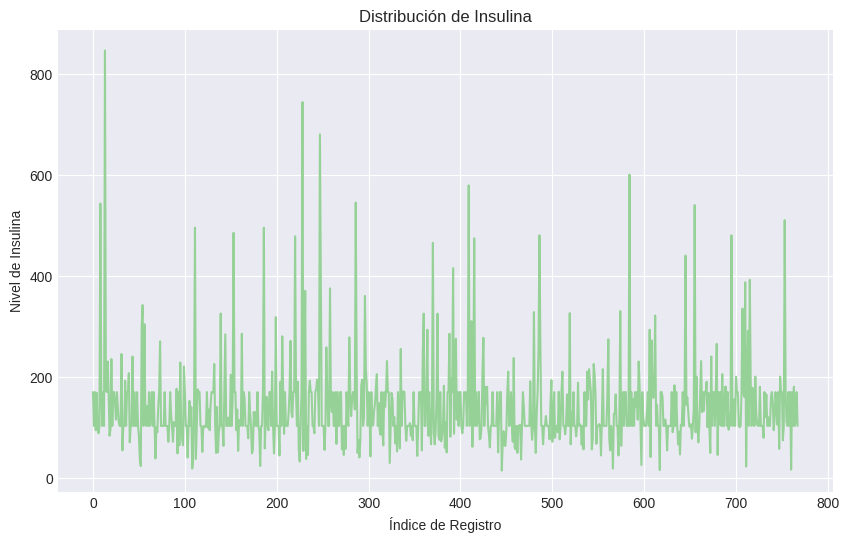

In [48]:
plt.figure(figsize=(10, 6)) # Aumentar el tamaño de la figura para una mejor visualización
completo.Insulin.plot.line()
plt.title('Distribución de Insulina') # Añadir un título para claridad
plt.xlabel('Índice de Registro') # Etiqueta del eje X
plt.ylabel('Nivel de Insulina') # Etiqueta del eje Y
plt.grid(True) # Asegurarse de que la cuadrícula esté visible
plt.show()

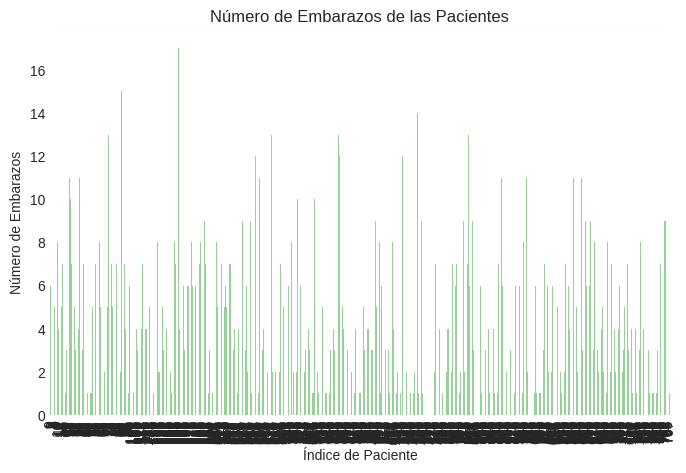

In [49]:
plt.figure(figsize=(8, 5))
completo.Pregnancies.plot.bar()
plt.title('Número de Embarazos de las Pacientes')
plt.xlabel('Índice de Paciente')
plt.ylabel('Número de Embarazos')
plt.grid(True)
plt.show()

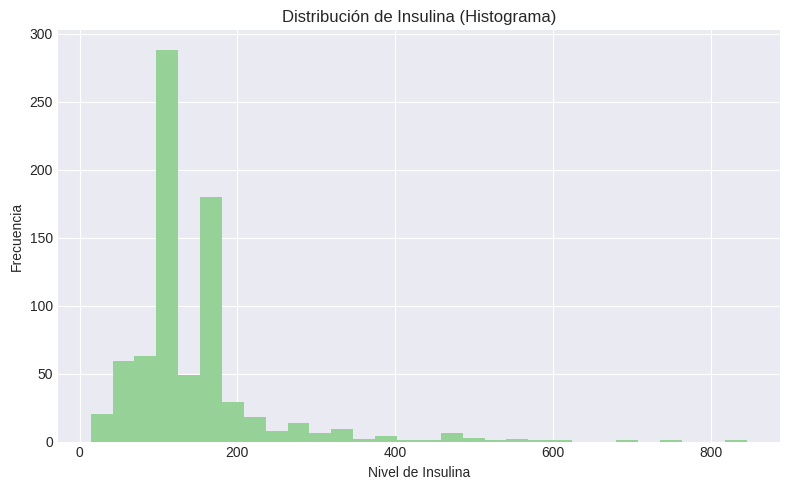

In [50]:
plt.figure(figsize=(8, 5))
ax = (completo.Insulin).plot.hist(bins=30) # Eliminar la división por 1 millón para mejor legibilidad
ax.set_title('Distribución de Insulina (Histograma)')
ax.set_xlabel("Nivel de Insulina")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

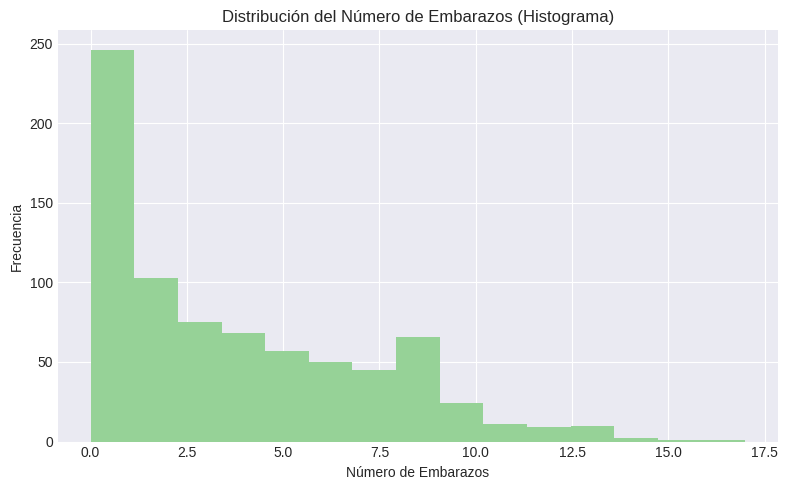

In [51]:
plt.figure(figsize=(8, 5))
ax = (completo.Pregnancies).plot.hist(bins=15) # Eliminar la división por 1 millón para mejor legibilidad
ax.set_title('Distribución del Número de Embarazos (Histograma)')
ax.set_xlabel("Número de Embarazos")
ax.set_ylabel("Frecuencia")
plt.tight_layout()
plt.show()

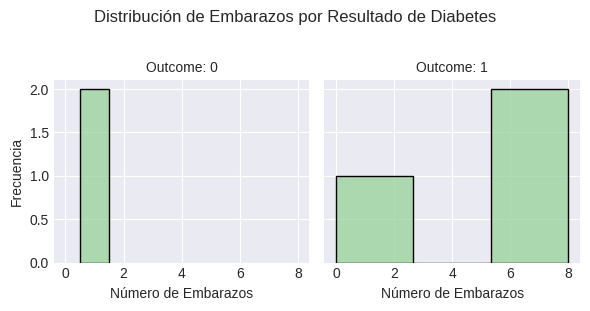

In [52]:
analisis = completo.head()
g = sns.FacetGrid(analisis, col="Outcome")
g.map(sns.histplot, "Pregnancies")
g.set_axis_labels("Número de Embarazos", "Frecuencia")
g.set_titles("Outcome: {col_name}")
plt.suptitle('Distribución de Embarazos por Resultado de Diabetes', y=1.02) # Título general
plt.tight_layout()
plt.show()

Estimación de la variabilidad

In [38]:
# Desviación estandar
completo.Insulin.std()

89.10084663622659

In [39]:
completo.Pregnancies.std()

3.3695780626988623

In [40]:
# Calculo del IQR
completo.Insulin.quantile(0.75) - completo.Insulin.quantile(0.25)

np.float64(67.0)

In [41]:
completo.Pregnancies.quantile(0.75) - completo.Pregnancies.quantile(0.25)

np.float64(5.0)

**Exploración de distribucion de datos con graficos**

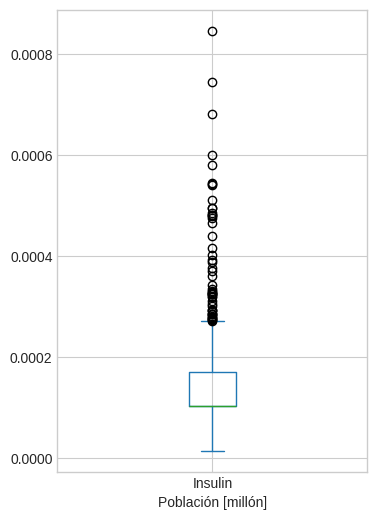

In [42]:
ax=(completo.Insulin/1_000_000).plot.box(figsize=(4,6))
ax.set_xlabel("Población [millón]")

plt.show()

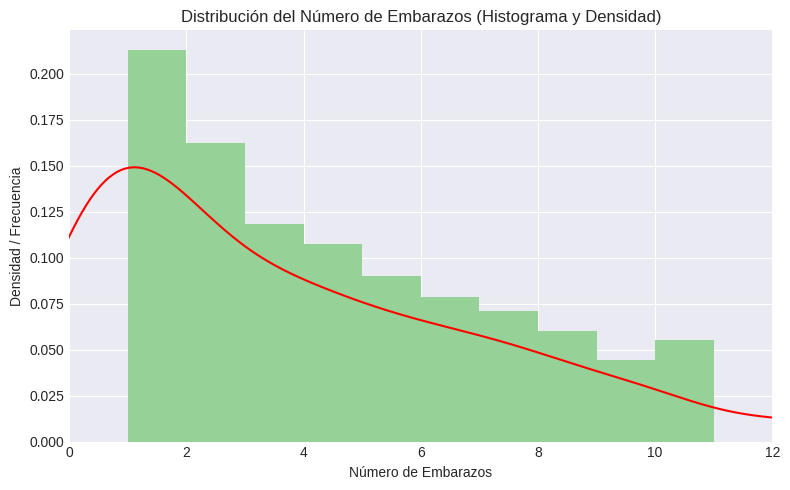

In [53]:
plt.figure(figsize=(8, 5))
ax=(completo["Pregnancies"]).plot.hist(density=True, xlim=[0,12], bins=range(1,12))
completo["Pregnancies"].plot.density(ax=ax, color='red') # Cambiar color de la densidad para contraste
ax.set_title('Distribución del Número de Embarazos (Histograma y Densidad)')
ax.set_xlabel("Número de Embarazos")
ax.set_ylabel("Densidad / Frecuencia")
plt.tight_layout()
plt.show()

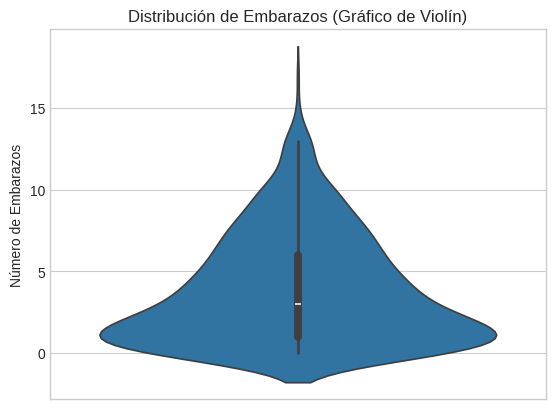

In [44]:
ax = sns.violinplot(y=completo["Pregnancies"])
ax.set_title("Distribución de Embarazos (Gráfico de Violín)")
ax.set_ylabel("Número de Embarazos")
plt.show()

In [45]:
mad_insulin = robust.mad(completo.Insulin)
mad_pregnancies = robust.mad(completo.Pregnancies)

print(f"Desviación Absoluta de la Mediana (MAD) - Insulina: {mad_insulin:.2f} mg/dL")
print(f"Desviación Absoluta de la Mediana (MAD) - Embarazos: {mad_pregnancies:.2f}")

# Comparación con la Desviación Estándar para ver el efecto de los outliers
print(f"\nDesviación Estándar (Insulina) para comparar: {completo.Insulin.std():.2f} mg/dL")

Desviación Absoluta de la Mediana (MAD) - Insulina: 54.11 mg/dL
Desviación Absoluta de la Mediana (MAD) - Embarazos: 2.97

Desviación Estándar (Insulina) para comparar: 89.10 mg/dL


## Personalizar el estilo de las gráficas

Podemos usar `seaborn` y `matplotlib` para cambiar el estilo de las gráficas. Aquí, estableceremos una paleta de colores verdes y un estilo general más 'elegante'.

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# Definir una paleta de colores verdes
green_palette = sns.color_palette("Greens_d", n_colors=9)

# Establecer la paleta y un estilo general elegante
sns.set_palette(green_palette)
plt.style.use('seaborn-v0_8-darkgrid') # Un estilo elegante con fondo oscuro y cuadrícula

print("Estilo y paleta de colores actualizados.")

Estilo y paleta de colores actualizados.


Ahora, veamos cómo se ve la gráfica de la **Insulina** con el nuevo estilo.

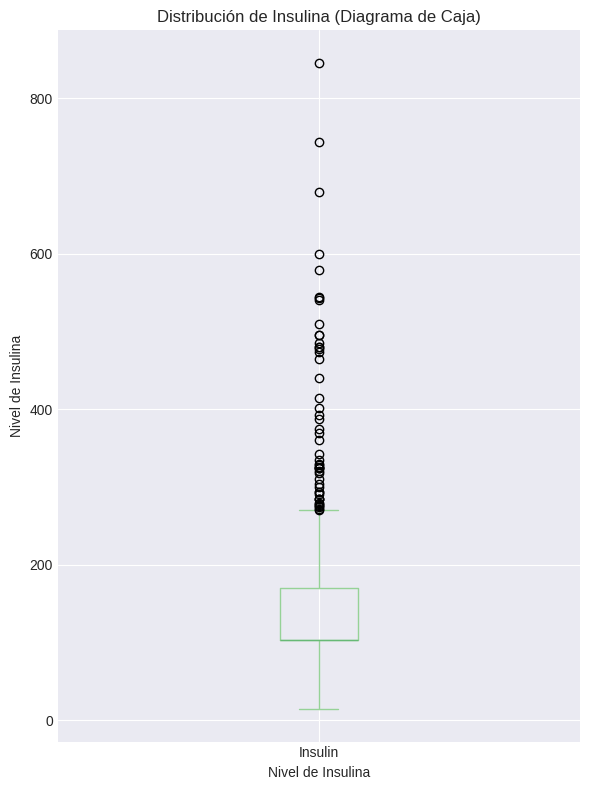

In [54]:
plt.figure(figsize=(6, 8))
ax=(completo.Insulin).plot.box() # Eliminar la división por 1 millón para mejor legibilidad
ax.set_title('Distribución de Insulina (Diagrama de Caja)')
ax.set_xlabel("Nivel de Insulina")
ax.set_ylabel("Nivel de Insulina") # Corregir etiqueta del eje Y
plt.tight_layout()
plt.show()

In [46]:
### ¿Se puede responder qué causa la diabetes con el análisis actual?

"""No, el análisis realizado hasta ahora es puramente descriptivo y exploratorio. Hemos examinado las distribuciones de variables individuales y algunas estadísticas básicas, lo cual nos ayuda a entender los datos, pero no es suficiente para establecer relaciones de causa y efecto. Para determinar qué causa la diabetes, necesitaríamos realizar análisis de correlación más profundos y aplicar modelos estadísticos o predictivos que cuantifiquen la influencia de cada característica en el Outcome (presencia de diabetes)."""

'No, el análisis realizado hasta ahora es puramente descriptivo y exploratorio. Hemos examinado las distribuciones de variables individuales y algunas estadísticas básicas, lo cual nos ayuda a entender los datos, pero no es suficiente para establecer relaciones de causa y efecto. Para determinar qué causa la diabetes, necesitaríamos realizar análisis de correlación más profundos y aplicar modelos estadísticos o predictivos que cuantifiquen la influencia de cada característica en el Outcome (presencia de diabetes).'